In [1]:

# Redefining Job Categorisation in the Gaming and Tech Industry Using Clustering Method
# -----------------------------------------------------------------------------------------

# 0) IMPORTS + REPRODUCIBILITY

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import silhouette_score, pairwise_distances, cohen_kappa_score
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

from scipy.stats import kendalltau

# Optional HDBSCAN
try:
    import hdbscan
    HDBSCAN_AVAILABLE = True
except ImportError:
    HDBSCAN_AVAILABLE = False
    print("⚠️ hdbscan not installed. HDBSCAN parts will be skipped.")

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

sns.set(style="whitegrid", rc={"figure.figsize": (10, 6)})
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.spines.top"] = False
pd.set_option("display.max_colwidth", 200)




In [2]:
# 1) LOAD DATA
# -----------------------------
DATA_PATH = "Combined Data.csv"  # change if needed
df_raw = pd.read_csv(DATA_PATH)
print("Raw shape:", df_raw.shape)
display(df_raw.head())



Raw shape: (70017, 17)


,Company Category,Company,Overall Job Category,Job Category,Title,Min Experience,Max Experience,Country,State,City,Location Type,JobType,Job Link,Activated Date,Skills,Min Salary,Max Salary
0,Tech Company,Ion,Engineering & Development,Programming,Senior Java Consultant,5.0,NaN,Hungary,NaN,Budapest,On-site,Full-time,https://jobs.lever.co/ion/5c5ca4f1-80ca-43d0-b672-0b641d087ed7,5 Aug 2025,"Unity, game-texts, kanban, agile-development, maven, restful-web-services, hibernate, ci-cd, front-end, scala, multithreading, java",NaN,NaN
1,Tech Company,Ion,Strategy & Consulting,Business-analysis,Principal Business Consultant - Openlink,5.0,10.0,United States,Texas,Houston,On-site,Full-time,https://jobs.lever.co/ion/69378aef-190c-4aec-b852-c94dd36f73a7,5 Aug 2025,"Communication, problem-solving, game-texts, accounting",NaN,NaN
2,Tech Company,Ion,IT & Security,It-&-infrastructure,Technical Support Analyst,NaN,NaN,Hong Kong,NaN,Hong Kong,On-site,Full-time,https://jobs.lever.co/ion/7576d933-df50-4d9d-a539-265c9af5fa4c,05 August 2025,"Communication, cpp, game-texts, unix",NaN,NaN
3,Tech Company,Ion,IT & Security,It-&-infrastructure,Technical Support Analyst,0.0,2.0,United Kingdom,England,Woking,On-site,Full-time,https://jobs.lever.co/ion/afbd8447-1de7-4f94-981d-fef78ea53f3e,5 Aug 2025,"Communication, cpp, game-texts, unix",NaN,NaN
4,Tech Company,Ion,Engineering & Development,Programming,Web Tech Lead,10.0,NaN,Mexico,Mexico City,NaN,Hybrid,Full-time,https://jobs.lever.co/ion/cdf62807-5a0e-4194-b166-3fda6821f30f,5 Aug 2025,"Team-management, communication, excel, bloomberg, game-texts, software-development-lifecycle-sdlc, agile-development, salesforce, react, azure, spring-boot, data-science, angular, typescript, java...",NaN,NaN


In [3]:
# 2) CLEANING & PREPROCESSING
# -----------------------------
df = df_raw.copy()
df.columns = [c.strip() for c in df.columns]

required_cols = ["Skills", "Country", "Overall Job Category", "Title"]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}. Please check your dataset.")

# Track rows for cleaning chart
n_raw = df.shape[0]

# Remove missing key fields
df = df[~df["Skills"].isna()]
n_after_skills = df.shape[0]

df = df[~df["Country"].isna()]
n_after_country = df.shape[0]

# Clean skills
junk_tokens = {
    "game-text", "game-texts",
    "only", "has", "and", "or", "etc", "na", "n/a", "none"
}

def clean_skills(skills_str):
    if pd.isna(skills_str):
        return ""
    tokens = [s.strip().lower() for s in str(skills_str).split(",")]
    tokens = [t for t in tokens if t and t not in junk_tokens]
    tokens = sorted(set(tokens))
    return ", ".join(tokens)

df["Skills_CLEAN"] = df["Skills"].apply(clean_skills)
df = df[df["Skills_CLEAN"] != ""]
n_final = df.shape[0]

print("After cleaning shape:", df.shape)
display(df[["Skills", "Skills_CLEAN"]].head())




After cleaning shape: (64230, 18)


,Skills,Skills_CLEAN
0,"Unity, game-texts, kanban, agile-development, maven, restful-web-services, hibernate, ci-cd, front-end, scala, multithreading, java","agile-development, ci-cd, front-end, hibernate, java, kanban, maven, multithreading, restful-web-services, scala, unity"
1,"Communication, problem-solving, game-texts, accounting","accounting, communication, problem-solving"
2,"Communication, cpp, game-texts, unix","communication, cpp, unix"
3,"Communication, cpp, game-texts, unix","communication, cpp, unix"
4,"Team-management, communication, excel, bloomberg, game-texts, software-development-lifecycle-sdlc, agile-development, salesforce, react, azure, spring-boot, data-science, angular, typescript, java...","agile-development, angular, azure, bloomberg, communication, data-science, excel, javascript, react, salesforce, software-development-lifecycle-sdlc, spring-boot, team-management, typescript"


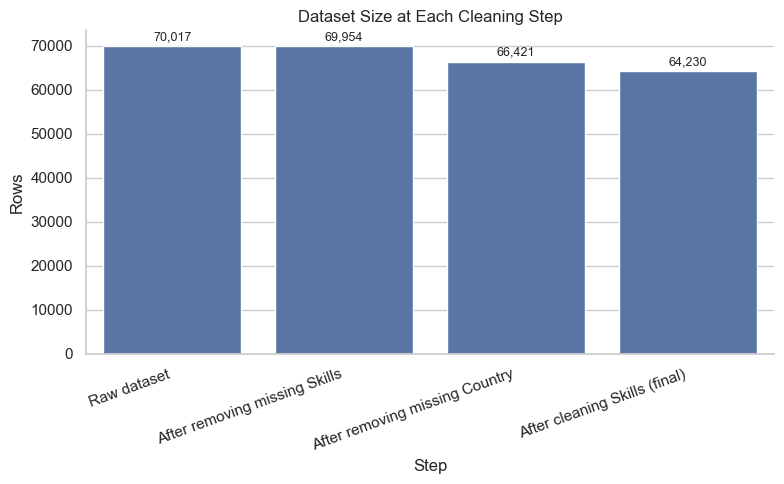

In [4]:
# Cleaning steps visual
clean_steps = pd.DataFrame({
    "Step": [
        "Raw dataset",
        "After removing missing Skills",
        "After removing missing Country",
        "After cleaning Skills (final)"
    ],
    "Rows": [n_raw, n_after_skills, n_after_country, n_final]
})

plt.figure(figsize=(8, 5))
sns.barplot(data=clean_steps, x="Step", y="Rows")
plt.title("Dataset Size at Each Cleaning Step")
plt.xticks(rotation=20, ha="right")
for i, v in enumerate(clean_steps["Rows"]):
    plt.text(i, v + n_raw * 0.01, f"{v:,}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()


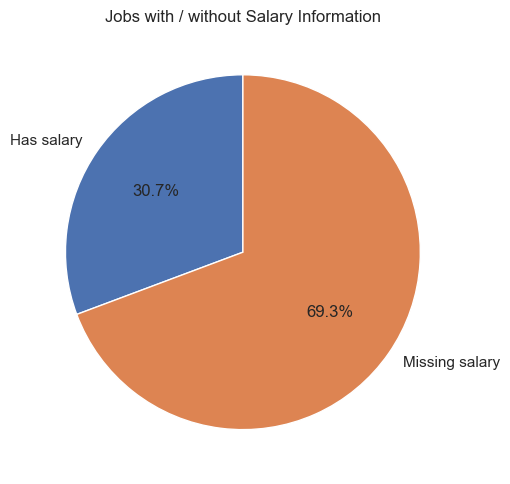

In [5]:
# 2.1) SALARY CLEANING
# -----------------------------
def parse_salary(x):
    if pd.isna(x):
        return np.nan
    x = str(x).replace("$", "").replace(",", "").strip()
    try:
        return float(x)
    except ValueError:
        return np.nan

if "Min Salary" in df.columns and "Max Salary" in df.columns:
    df["Min Salary_num"] = df["Min Salary"].apply(parse_salary)
    df["Max Salary_num"] = df["Max Salary"].apply(parse_salary)
    df["Mid_Salary"] = df[["Min Salary_num", "Max Salary_num"]].mean(axis=1)
else:
    df["Mid_Salary"] = np.nan

plt.figure(figsize=(6, 5))
labels = ["Has salary", "Missing salary"]
sizes = [df["Mid_Salary"].notna().sum(), df["Mid_Salary"].isna().sum()]
plt.pie(sizes, labels=labels, autopct="%1.1f%%", startangle=90)
plt.title("Jobs with / without Salary Information")
plt.tight_layout()
plt.show()




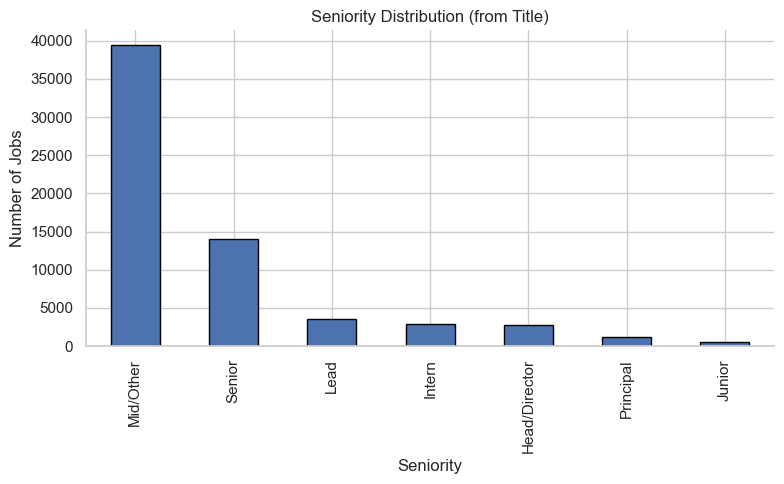

In [6]:
# 2.2) SENIORITY FROM TITLE
# -----------------------------
def extract_seniority(title):
    if pd.isna(title):
        return "Unspecified"
    t = str(title).lower()
    if "intern" in t or "trainee" in t:
        return "Intern"
    if "junior" in t or "jr " in t or t.startswith("jr"):
        return "Junior"
    if "senior" in t or "sr " in t or t.startswith("sr"):
        return "Senior"
    if "lead" in t:
        return "Lead"
    if "principal" in t:
        return "Principal"
    if "head" in t or "director" in t:
        return "Head/Director"
    return "Mid/Other"

df["Seniority"] = df["Title"].apply(extract_seniority)

plt.figure(figsize=(8, 5))
df["Seniority"].value_counts().plot(kind="bar", edgecolor="black")
plt.title("Seniority Distribution (from Title)")
plt.ylabel("Number of Jobs")
plt.tight_layout()
plt.show()




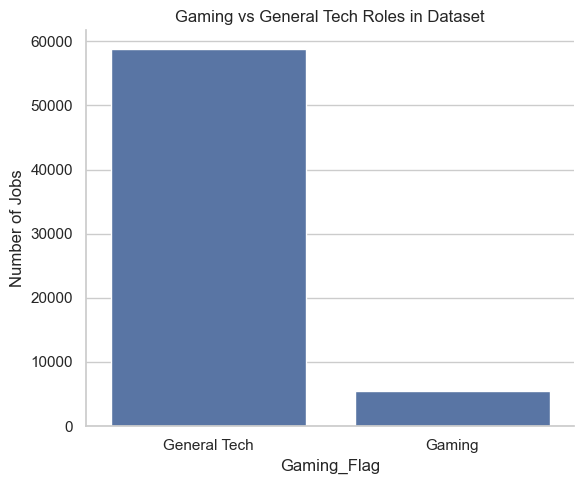

In [7]:
# 2.3) GAMING VS GENERAL TECH FLAG
# -----------------------------
gaming_keywords = [
    "game", "gaming", "unity", "unreal", "ue4", "ue5",
    "gamedev", "gameplay", "level design", "3d", "2d"
]

def has_gaming_keyword(text):
    if pd.isna(text):
        return 0
    t = str(text).lower()
    return int(any(k in t for k in gaming_keywords))

df["Gaming_Flag"] = (
    df["Title"].apply(has_gaming_keyword) |
    df["Skills_CLEAN"].apply(has_gaming_keyword)
).astype(int)

counts = df["Gaming_Flag"].map({1: "Gaming", 0: "General Tech"}).value_counts()
plt.figure(figsize=(6, 5))
sns.barplot(x=counts.index, y=counts.values)
plt.title("Gaming vs General Tech Roles in Dataset")
plt.ylabel("Number of Jobs")
plt.tight_layout()
plt.show()




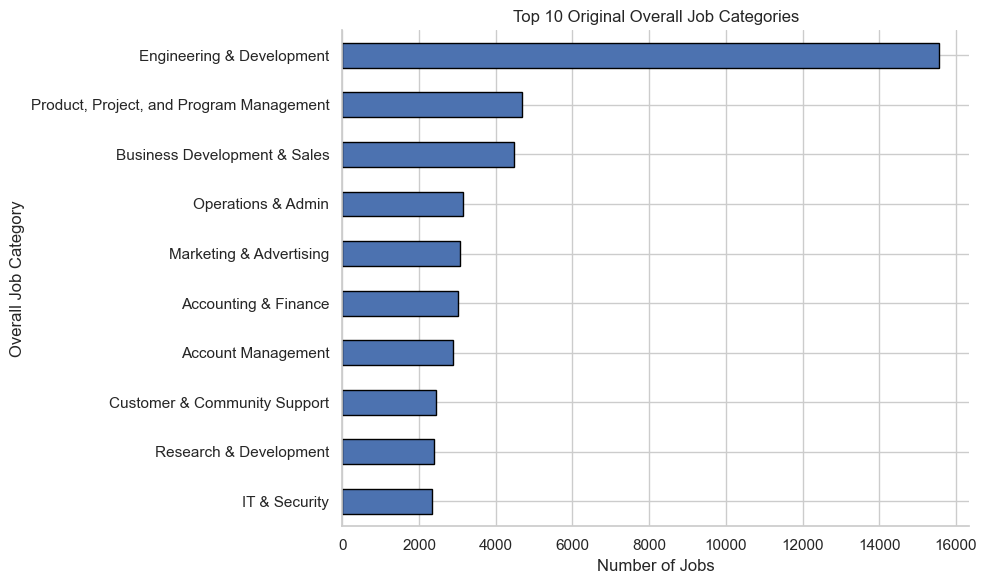

In [8]:
# 3) ORIGINAL TAXONOMY OVERVIEW
# -----------------------------
plt.figure(figsize=(10, 6))
df["Overall Job Category"].value_counts().head(10).sort_values().plot(kind="barh", edgecolor="black")
plt.title("Top 10 Original Overall Job Categories")
plt.xlabel("Number of Jobs")
plt.tight_layout()
plt.show()



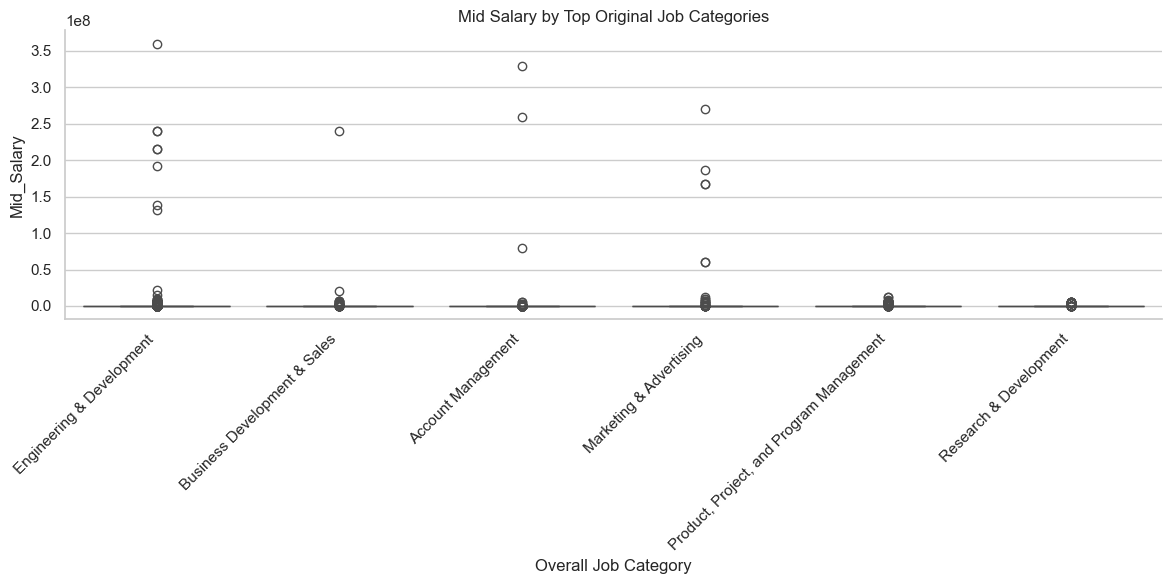

In [9]:
df_salary_only = df[df["Mid_Salary"].notna()].copy()
if not df_salary_only.empty:
    top_old_for_salary = df_salary_only["Overall Job Category"].value_counts().head(6).index
    plt.figure(figsize=(12, 6))
    sns.boxplot(
        data=df_salary_only[df_salary_only["Overall Job Category"].isin(top_old_for_salary)],
        x="Overall Job Category",
        y="Mid_Salary"
    )
    plt.xticks(rotation=45, ha="right")
    plt.title("Mid Salary by Top Original Job Categories")
    plt.tight_layout()
    plt.show()


In [10]:
# 4) TF-IDF VECTORISATION (SKILLS)
# -----------------------------
tfidf = TfidfVectorizer(
    token_pattern=r"(?u)\b\w+\b",
    min_df=5,
    max_df=0.9
)
X_tfidf = tfidf.fit_transform(df["Skills_CLEAN"])
feature_names = np.array(tfidf.get_feature_names_out())
print("TF-IDF shape:", X_tfidf.shape)




TF-IDF shape: (64230, 667)


In [11]:
# 5) CLUSTERING: KMEANS +  HDBSCAN
# -----------------------------
results = []
X_red = None  # if we run SVD

# KMeans baseline (k = original category count)
orig_cat_count = df["Overall Job Category"].nunique()
km_base = KMeans(n_clusters=orig_cat_count, random_state=SEED, n_init=15)
labels_base = km_base.fit_predict(X_tfidf)
sil_base = silhouette_score(X_tfidf, labels_base)
results.append({
    "method": f"KMeans_k{orig_cat_count}",
    "labels": labels_base,
    "model": km_base,
    "space": "tfidf",
    "silhouette": float(sil_base),
    "n_clusters": int(orig_cat_count)
})
print(f"KMeans baseline k={orig_cat_count}, silhouette={sil_base:.3f}")



KMeans baseline k=32, silhouette=0.086


In [12]:
# K search
k_values = list(range(20, 121, 10))
sils = []
for k in k_values:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    labs = km.fit_predict(X_tfidf)
    sil = silhouette_score(X_tfidf, labs)
    sils.append(float(sil))
    results.append({
        "method": f"KMeans_k{k}",
        "labels": labs,
        "model": km,
        "space": "tfidf",
        "silhouette": float(sil),
        "n_clusters": int(k)
    })
    print(f"KMeans k={k}, silhouette={sil:.3f}")





KMeans k=20, silhouette=0.070
KMeans k=30, silhouette=0.084
KMeans k=40, silhouette=0.090
KMeans k=50, silhouette=0.090
KMeans k=60, silhouette=0.095
KMeans k=70, silhouette=0.096
KMeans k=80, silhouette=0.100
KMeans k=90, silhouette=0.102
KMeans k=100, silhouette=0.104
KMeans k=110, silhouette=0.106
KMeans k=120, silhouette=0.111


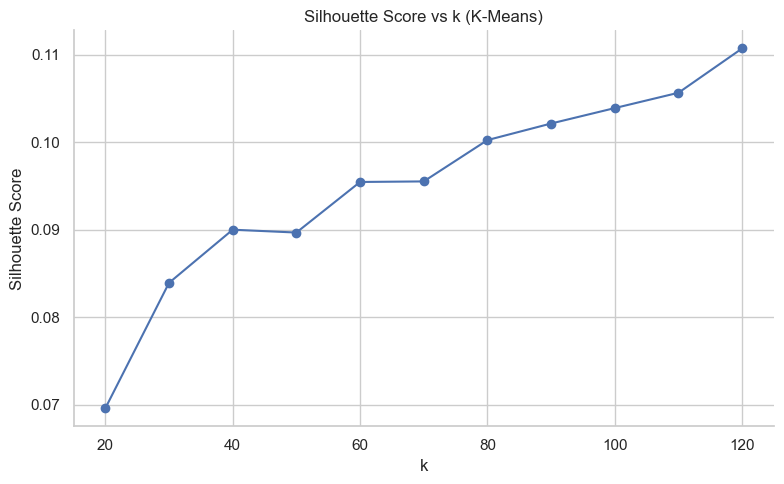

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(k_values, sils, marker="o")
plt.title("Silhouette Score vs k (K-Means)")
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.tight_layout()
plt.show()

In [14]:
# HDBSCAN
if HDBSCAN_AVAILABLE:
    svd = TruncatedSVD(n_components=50, random_state=SEED)
    X_red = svd.fit_transform(X_tfidf)

    clusterer = hdbscan.HDBSCAN(min_cluster_size=40, min_samples=10)
    labels_hdb = clusterer.fit_predict(X_red)

    mask_non_noise = labels_hdb != -1
    if mask_non_noise.sum() > 1 and len(set(labels_hdb[mask_non_noise])) > 1:
        sil_hdb = silhouette_score(X_red[mask_non_noise], labels_hdb[mask_non_noise])
    else:
        sil_hdb = -1.0

    n_clust_hdb = len(set(labels_hdb)) - (1 if -1 in labels_hdb else 0)
    results.append({
        "method": "HDBSCAN",
        "labels": labels_hdb,
        "model": clusterer,
        "space": "svd",
        "silhouette": float(sil_hdb),
        "n_clusters": int(n_clust_hdb)
    })
    print(f"HDBSCAN clusters={n_clust_hdb}, silhouette={sil_hdb:.3f}")




HDBSCAN clusters=102, silhouette=0.726


In [15]:
# 6) FINAL MODEL SELECTION (RESEARCH)
# ------------------------------------------
MIN_CLUSTERS = 8
MAX_CLUSTERS = 60

def score_result(r):
    if r["n_clusters"] is None:
        return -np.inf
    if r["n_clusters"] < MIN_CLUSTERS or r["n_clusters"] > MAX_CLUSTERS:
        return -np.inf
    if np.isnan(r["silhouette"]):
        return -np.inf

    sil = r["silhouette"]
    k_penalty = 0.002 * r["n_clusters"]  # mild interpretability penalty

    noise_penalty = 0
    if "HDBSCAN" in r["method"]:
        labels = r["labels"]
        noise_ratio = (labels == -1).mean()
        noise_penalty = 0.15 * noise_ratio  # penalize heavy noise

    return sil - k_penalty - noise_penalty

valid = [r for r in results if score_result(r) > -np.inf]
best = max(valid, key=score_result)

print("\n Final model selected:", best["method"])
print("   clusters:", best["n_clusters"])
print("   silhouette:", best["silhouette"])

df["Cluster_ID_raw"] = best["labels"]  # keep raw assignment
best_model = best["model"]
best_space = best["space"]



 Final model selected: KMeans_k20
   clusters: 20
   silhouette: 0.06958407618484444


In [16]:
# 7) CLUSTER CONFIDENCE ( EXPLICIT 'UNCERTAIN/HYBRID' < 0.5)
# --------------------------------------------------------------
if "HDBSCAN" in best["method"] and hasattr(best_model, "probabilities_"):
    conf = best_model.probabilities_
    conf = np.where(df["Cluster_ID_raw"].values == -1, 0, conf)
    df["Cluster_Conf"] = conf
else:
    X_used = X_tfidf if best_space == "tfidf" else X_red
    centers = best_model.cluster_centers_
    labels = df["Cluster_ID_raw"].values

    dists = pairwise_distances(X_used, centers, metric="euclidean")
    dist_to_own = dists[np.arange(len(labels)), labels]

    min_d, max_d = float(dist_to_own.min()), float(dist_to_own.max())
    if max_d == min_d:
        df["Cluster_Conf"] = 0.5
    else:
        df["Cluster_Conf"] = 1 - (dist_to_own - min_d) / (max_d - min_d)

# Confidence levels
df["Conf_Level"] = pd.cut(
    df["Cluster_Conf"],
    bins=[0.0, 0.5, 0.75, 1.0],
    labels=["Low (<0.5)", "Medium (0.5–0.75)", "High (>0.75)"],
    include_lowest=True
)

# NEW: Explicit "clustered vs unclustered" definition using confidence threshold
CONF_UNCERTAIN_THR = 0.50
df["Clustered_Flag"] = (df["Cluster_Conf"] >= CONF_UNCERTAIN_THR).astype(int)

# Create final cluster id that marks uncertain jobs as -1
df["Cluster_ID"] = df["Cluster_ID_raw"]
df.loc[df["Clustered_Flag"] == 0, "Cluster_ID"] = -1

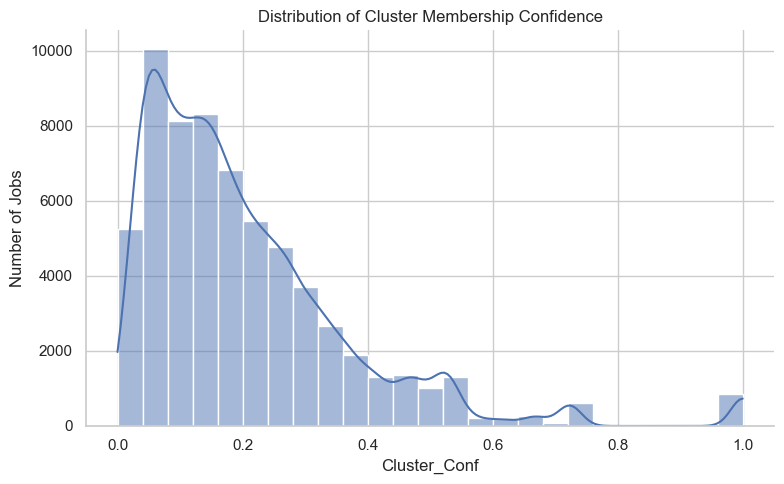

In [17]:
# Confidence visuals
plt.figure(figsize=(8, 5))
sns.histplot(df["Cluster_Conf"], bins=25, kde=True)
plt.title("Distribution of Cluster Membership Confidence")
plt.xlabel("Cluster_Conf")
plt.ylabel("Number of Jobs")
plt.tight_layout()
plt.show()




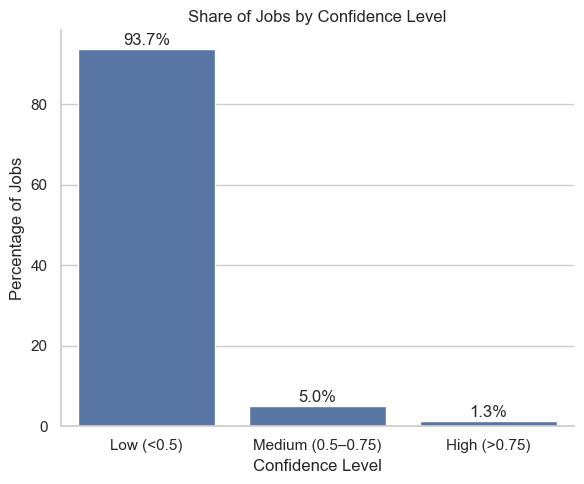

In [18]:
conf_counts = df["Conf_Level"].value_counts(normalize=True).mul(100).round(1)
plt.figure(figsize=(6, 5))
sns.barplot(x=conf_counts.index, y=conf_counts.values)
plt.title("Share of Jobs by Confidence Level")
plt.ylabel("Percentage of Jobs")
plt.xlabel("Confidence Level")
for i, v in enumerate(conf_counts.values):
    plt.text(i, v + 1, f"{v:.1f}%", ha="center")
plt.tight_layout()
plt.show()


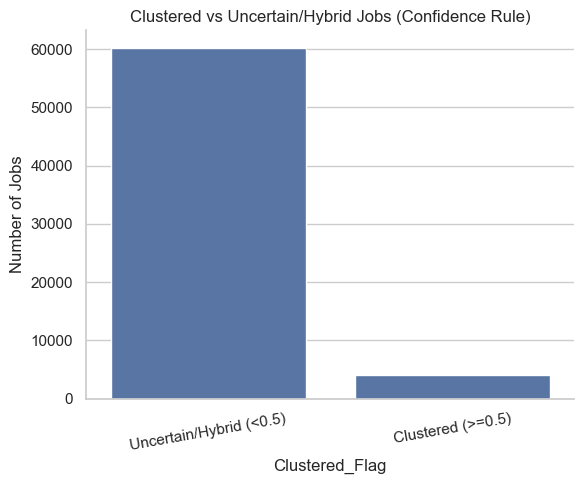

In [19]:
# NEW: Clustered vs Uncertain share
plt.figure(figsize=(6, 5))
tmp = df["Clustered_Flag"].map({1: "Clustered (>=0.5)", 0: "Uncertain/Hybrid (<0.5)"}).value_counts()
sns.barplot(x=tmp.index, y=tmp.values)
plt.title("Clustered vs Uncertain/Hybrid Jobs (Confidence Rule)")
plt.ylabel("Number of Jobs")
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()



In [20]:
# 8) NAMING CLUSTERS + 'UNCERTAIN/HYBRID'
# ---------------------------------------------
def name_clusters(labels, matrix, features, top_n=6):
    names = {}
    for cl in sorted(set(labels)):
        if cl == -1:
            names[cl] = "Uncertain/Hybrid (low confidence)"
            continue
        idx = np.where(labels == cl)[0]
        if len(idx) == 0:
            names[cl] = f"Cluster {cl}"
            continue
        centroid = matrix[idx].mean(axis=0)
        centroid = np.asarray(centroid).ravel()
        top_idx = centroid.argsort()[::-1][:top_n]
        names[cl] = ", ".join(features[top_idx])
    return names

cluster_names = name_clusters(df["Cluster_ID"].values, X_tfidf, feature_names, top_n=6)
df["New_Job_Group"] = df["Cluster_ID"].map(cluster_names)

display(df[["Title", "Overall Job Category", "New_Job_Group", "Cluster_Conf", "Conf_Level"]].head(10))




,Title,Overall Job Category,New_Job_Group,Cluster_Conf,Conf_Level
0,Senior Java Consultant,Engineering & Development,Uncertain/Hybrid (low confidence),0.051792,Low (<0.5)
1,Principal Business Consultant - Openlink,Strategy & Consulting,Uncertain/Hybrid (low confidence),0.332104,Low (<0.5)
2,Technical Support Analyst,IT & Security,Uncertain/Hybrid (low confidence),0.048391,Low (<0.5)
3,Technical Support Analyst,IT & Security,Uncertain/Hybrid (low confidence),0.048391,Low (<0.5)
4,Web Tech Lead,Engineering & Development,Uncertain/Hybrid (low confidence),0.078477,Low (<0.5)
5,Tech Lead (Angular),Engineering & Development,Uncertain/Hybrid (low confidence),0.073196,Low (<0.5)
6,Senior Technical Consultant - Openlink,Engineering & Development,Uncertain/Hybrid (low confidence),0.067148,Low (<0.5)
7,"FP&A Analyst, Italy",Accounting & Finance,Uncertain/Hybrid (low confidence),0.159296,Low (<0.5)
8,Senior Technical Consultant - Openlink,Engineering & Development,Uncertain/Hybrid (low confidence),0.067148,Low (<0.5)
9,Trading Support Analyst,Accounting & Finance,Uncertain/Hybrid (low confidence),0.180840,Low (<0.5)


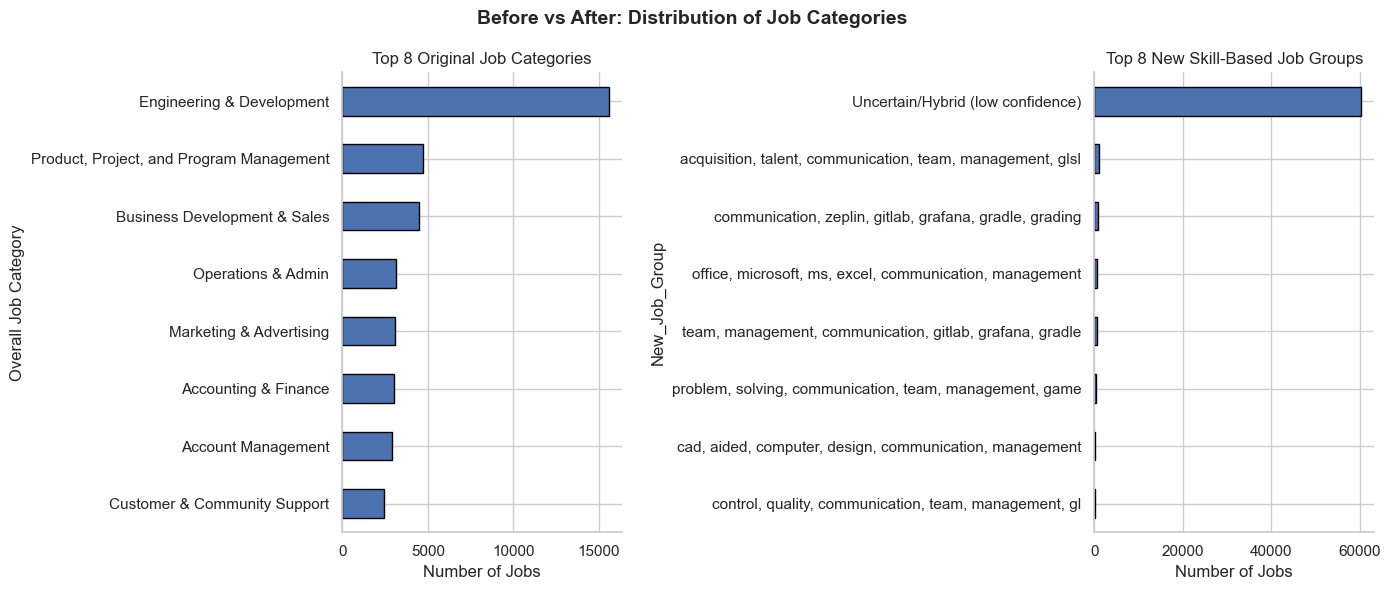

In [21]:
# 9) OLD VS NEW DISTRIBUTIONS + MAPPING
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

df["Overall Job Category"].value_counts().head(8).sort_values().plot(kind="barh", ax=axes[0], edgecolor="black")
axes[0].set_title("Top 8 Original Job Categories")
axes[0].set_xlabel("Number of Jobs")

df["New_Job_Group"].value_counts().head(8).sort_values().plot(kind="barh", ax=axes[1], edgecolor="black")
axes[1].set_title("Top 8 New Skill-Based Job Groups")
axes[1].set_xlabel("Number of Jobs")

plt.suptitle("Before vs After: Distribution of Job Categories", fontsize=14, weight="bold")
plt.tight_layout()
plt.show()



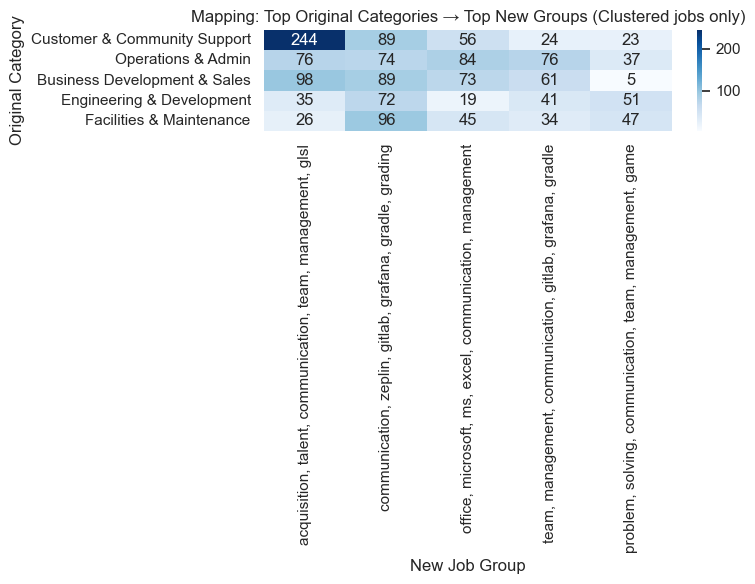

In [22]:
# Mapping heatmap (top 5 x top 5), excluding uncertain if you want clarity:
df_mapped = df[df["Cluster_ID"] != -1].copy()

cross = pd.crosstab(df_mapped["Overall Job Category"], df_mapped["New_Job_Group"])
top_old = cross.sum(axis=1).sort_values(ascending=False).head(5).index
top_new = cross.sum(axis=0).sort_values(ascending=False).head(5).index
cross_small = cross.loc[top_old, top_new]

plt.figure(figsize=(8, 6))
sns.heatmap(cross_small, annot=True, fmt="d", cmap="Blues")
plt.title("Mapping: Top Original Categories → Top New Groups (Clustered jobs only)")
plt.ylabel("Original Category")
plt.xlabel("New Job Group")
plt.tight_layout()
plt.show()


C:\Users\abira\AppData\Local\Temp\ipykernel_19944\3346969068.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha="right")
C:\Users\abira\AppData\Local\Temp\ipykernel_19944\3346969068.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha="right")


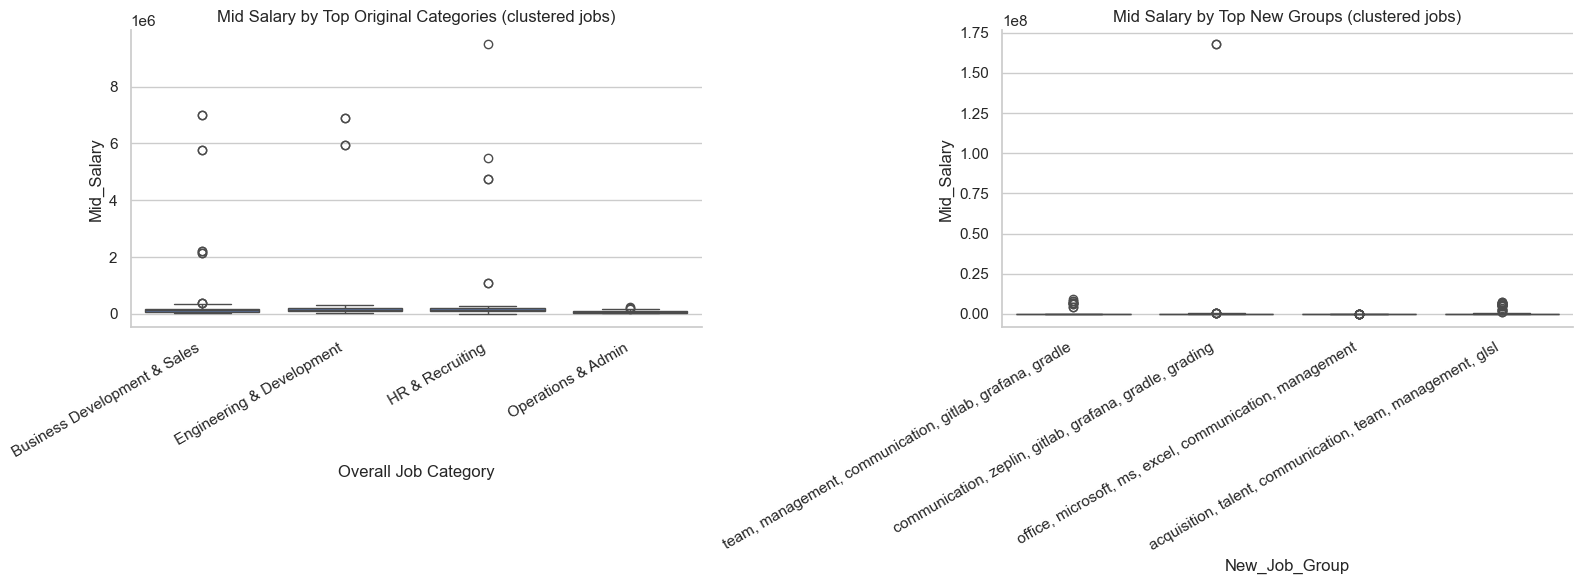

In [23]:
# 10) SALARY + LOCATION COMPARISONS (FOR STRONG LOCATION ANALYSIS)
# -----------------------------
df_salary = df[df["Mid_Salary"].notna()].copy()

# Salary old vs new (clustered only for cleaner comparison)
df_salary_clustered = df_salary[df_salary["Cluster_ID"] != -1].copy()

if not df_salary_clustered.empty:
    top_old_sal = df_salary_clustered["Overall Job Category"].value_counts().head(4).index
    top_new_sal = df_salary_clustered["New_Job_Group"].value_counts().head(4).index

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    sns.boxplot(
        data=df_salary_clustered[df_salary_clustered["Overall Job Category"].isin(top_old_sal)],
        x="Overall Job Category",
        y="Mid_Salary",
        ax=axes[0]
    )
    axes[0].set_title("Mid Salary by Top Original Categories (clustered jobs)")
    axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha="right")

    sns.boxplot(
        data=df_salary_clustered[df_salary_clustered["New_Job_Group"].isin(top_new_sal)],
        x="New_Job_Group",
        y="Mid_Salary",
        ax=axes[1]
    )
    axes[1].set_title("Mid Salary by Top New Groups (clustered jobs)")
    axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha="right")

    plt.tight_layout()
    plt.show()
else:
    print("Not enough salary rows for clustered-only salary comparison.")



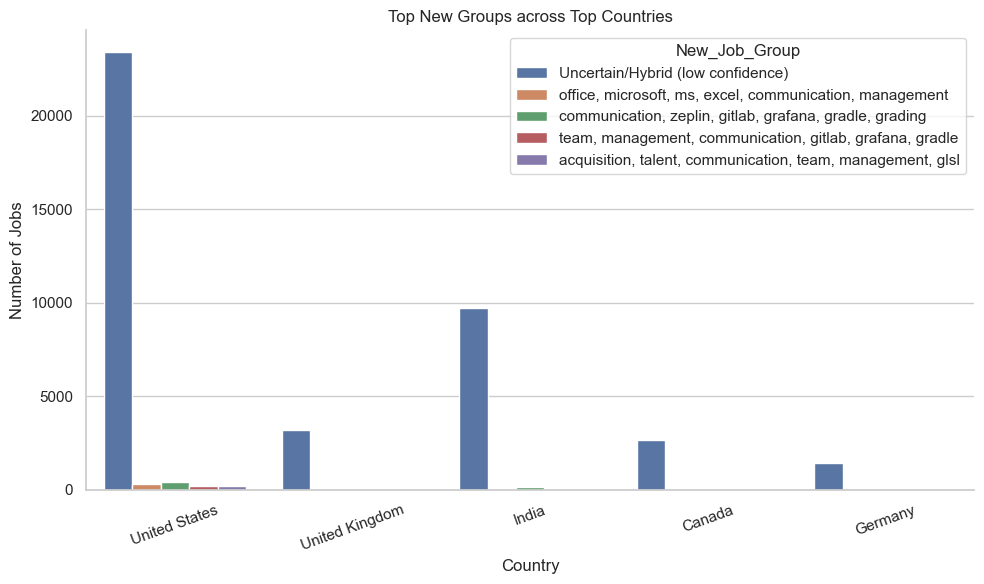

In [24]:
# Location distribution of new groups
top_countries = df["Country"].value_counts().head(5).index
df_loc = df[df["Country"].isin(top_countries)].copy()
top_new_loc = df_loc["New_Job_Group"].value_counts().head(5).index

plt.figure(figsize=(10, 6))
sns.countplot(
    data=df_loc[df_loc["New_Job_Group"].isin(top_new_loc)],
    x="Country",
    hue="New_Job_Group"
)
plt.title("Top New Groups across Top Countries")
plt.xticks(rotation=20)
plt.ylabel("Number of Jobs")
plt.tight_layout()
plt.show()



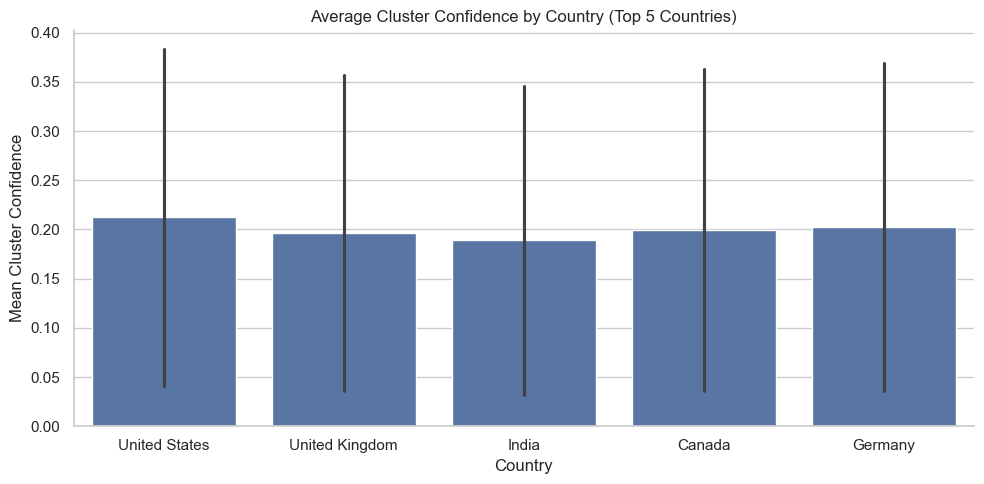

In [25]:
# Confidence by country (shows if clustering is stronger in some regions)
plt.figure(figsize=(10, 5))
sns.barplot(data=df_loc, x="Country", y="Cluster_Conf", estimator=np.mean, errorbar="sd")
plt.title("Average Cluster Confidence by Country (Top 5 Countries)")
plt.ylabel("Mean Cluster Confidence")
plt.tight_layout()
plt.show()



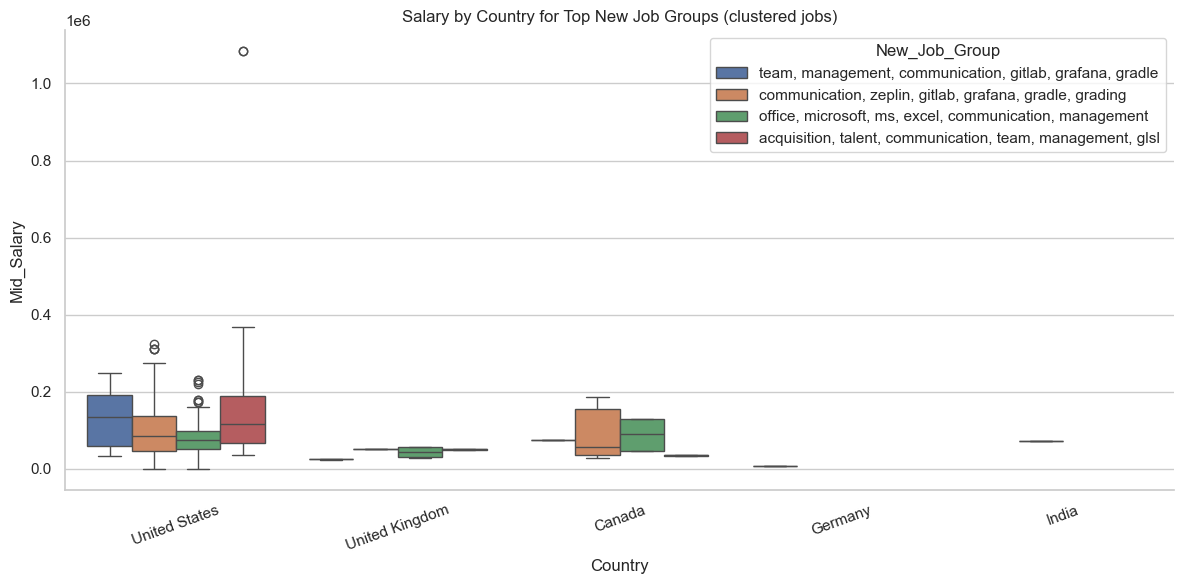

In [26]:
# Salary by country for top clusters (clustered jobs only)
if not df_salary_clustered.empty:
    top_clusters = df_salary_clustered["New_Job_Group"].value_counts().head(4).index
    df_sc = df_salary_clustered[df_salary_clustered["New_Job_Group"].isin(top_clusters) & df_salary_clustered["Country"].isin(top_countries)].copy()

    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df_sc, x="Country", y="Mid_Salary", hue="New_Job_Group")
    plt.title("Salary by Country for Top New Job Groups (clustered jobs)")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()




In [27]:
# 11) AGREEMENT METRIC: COHEN'S KAPPA (WITH AND WITHOUT UNCERTAIN)
# --------------------------------------------------------------------

# Kappa only makes sense on clustered items (not the 'uncertain' bucket)
df_k = df[df["Cluster_ID"] != -1].copy()

orig_codes = df_k["Overall Job Category"].astype("category").cat.codes
new_codes  = df_k["New_Job_Group"].astype("category").cat.codes

kappa_all = cohen_kappa_score(orig_codes, new_codes)
print("\nCohen's kappa (clustered jobs):", round(float(kappa_all), 3))

mask_high = df_k["Conf_Level"] == "High (>0.75)"
if mask_high.sum() > 0:
    kappa_high = cohen_kappa_score(orig_codes[mask_high], new_codes[mask_high])
    print("Cohen's kappa (high-confidence clustered only):", round(float(kappa_high), 3))
else:
    print("No high-confidence clustered jobs to compute kappa_high.")



Cohen's kappa (clustered jobs): -0.005
Cohen's kappa (high-confidence clustered only): 0.0


In [28]:
# 12) KENDALL'S TAU (SYSTEMATIC) + VISUAL
# ------------------------------------------
# Build exploded skill table
df_sk = df[["Overall Job Category", "New_Job_Group", "Skills_CLEAN", "Cluster_ID"]].copy()
df_sk["Skills_List"] = df_sk["Skills_CLEAN"].fillna("").str.split(",")
df_sk = df_sk.explode("Skills_List")
df_sk["Skills_List"] = df_sk["Skills_List"].str.strip().str.lower()
df_sk = df_sk[df_sk["Skills_List"] != ""]

topN_skills = 60
top_skills = df_sk["Skills_List"].value_counts().head(topN_skills).index

def skill_rank(series):
    counts = series.value_counts()
    s = counts.reindex(top_skills).fillna(0)
    return s.rank(method="average", ascending=False)

# Systematic: compute Kendall for top original categories against their dominant new group
TOP_CATS = 10
top_categories = df["Overall Job Category"].value_counts().head(TOP_CATS).index

kendall_rows = []
for cat in top_categories:
    # dominant new group among clustered jobs in that category
    subset = df[(df["Overall Job Category"] == cat) & (df["Cluster_ID"] != -1)]
    if subset.empty:
        continue
    dom_new = subset["New_Job_Group"].value_counts().idxmax()

    r_old = skill_rank(df_sk[df_sk["Overall Job Category"] == cat]["Skills_List"])
    r_new = skill_rank(df_sk[df_sk["New_Job_Group"] == dom_new]["Skills_List"])

    tau, p = kendalltau(r_old, r_new)
    kendall_rows.append({"Original_Category": cat, "Dominant_New_Group": dom_new, "Kendall_Tau": tau, "p_value": p})

kendall_df = pd.DataFrame(kendall_rows).sort_values("Kendall_Tau", ascending=False)
display(kendall_df)






,Original_Category,Dominant_New_Group,Kendall_Tau,p_value
3,Operations & Admin,"office, microsoft, ms, excel, communication, management",0.675100,1.442709e-12
5,Accounting & Finance,"office, microsoft, ms, excel, communication, management",0.566960,2.853741e-09
6,Account Management,"office, microsoft, ms, excel, communication, management",0.514813,7.291355e-08
7,Customer & Community Support,"acquisition, talent, communication, team, management, glsl",0.310196,3.550994e-03
9,IT & Security,"problem, solving, communication, team, management, game",0.306849,3.954883e-03
2,Business Development & Sales,"acquisition, talent, communication, team, management, glsl",0.306762,3.954892e-03
8,Research & Development,"acquisition, talent, communication, team, management, glsl",0.263380,1.332979e-02
4,Marketing & Advertising,"communication, zeplin, gitlab, grafana, gradle, grading",0.183040,8.844526e-02
1,"Product, Project, and Program Management","communication, zeplin, gitlab, grafana, gradle, grading",0.182677,8.848067e-02
0,Engineering & Development,"communication, zeplin, gitlab, grafana, gradle, grading",0.182574,8.848952e-02


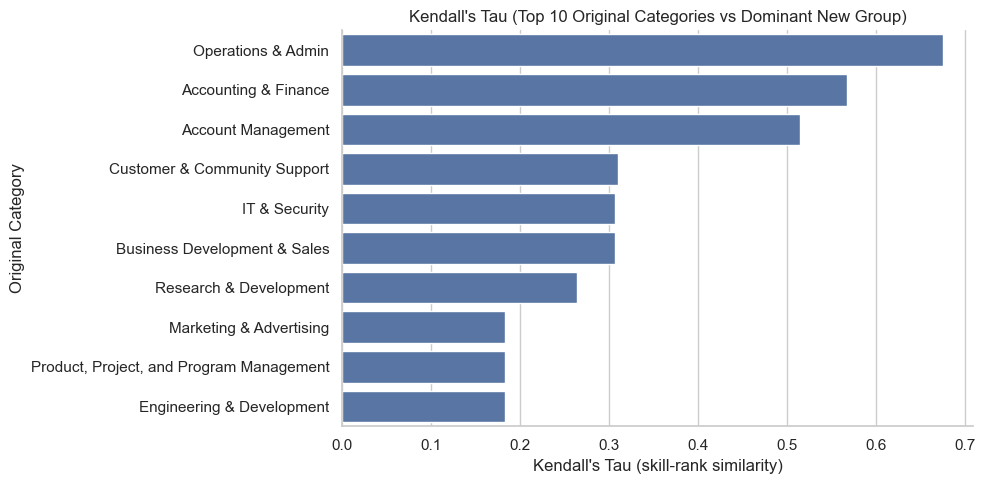

In [29]:
plt.figure(figsize=(10, 5))
sns.barplot(data=kendall_df, x="Kendall_Tau", y="Original_Category")
plt.title(f"Kendall's Tau (Top {TOP_CATS} Original Categories vs Dominant New Group)")
plt.xlabel("Kendall's Tau (skill-rank similarity)")
plt.ylabel("Original Category")
plt.tight_layout()
plt.show()

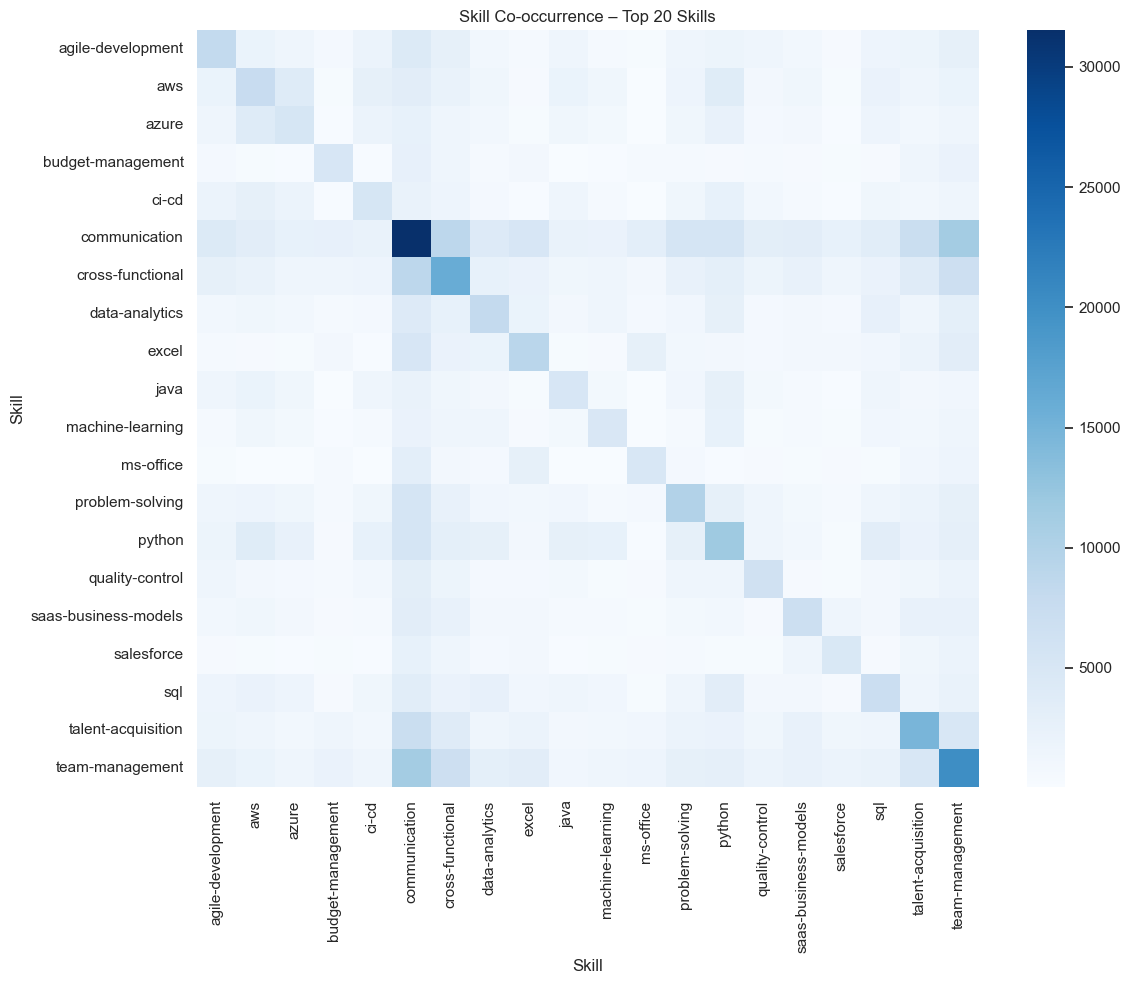

In [30]:
# 13) SKILL CO-OCCURRENCE HEATMAP (TOP 20 SKILLS)
# --------------------------------------------------
top_skills_20 = df_sk["Skills_List"].value_counts().head(20).index
df_top = df_sk[df_sk["Skills_List"].isin(top_skills_20)].copy()
df_top["value"] = 1

# stable job id
df_top["JobRowID"] = df_top.index

job_skill = df_top.pivot_table(
    index="JobRowID",
    columns="Skills_List",
    values="value",
    fill_value=0
)

cooc = job_skill.T.dot(job_skill)

plt.figure(figsize=(12, 10))
sns.heatmap(cooc, cmap="Blues")
plt.title("Skill Co-occurrence – Top 20 Skills")
plt.ylabel("Skill")
plt.xlabel("Skill")
plt.tight_layout()
plt.show()




In [31]:
# 14) CONFIDENCE THRESHOLD EXPERIMENTS (COVERAGE VS PURITY VS CLUSTERS)
# ------------------------------------------------------------------------
thresholds = [0.4, 0.5, 0.6, 0.7, 0.8]
rows = []

for thr in thresholds:
    mask = df["Cluster_Conf"] >= thr
    jobs_kept = int(mask.sum())
    pct_kept = float(jobs_kept / len(df) * 100)

    # clusters active among kept jobs excluding uncertain bucket definition here
    kept_clusters = df.loc[mask, "Cluster_ID_raw"].nunique()
    # purity vs original among kept jobs (raw clusters)
    ct = pd.crosstab(df.loc[mask, "Cluster_ID_raw"], df.loc[mask, "Overall Job Category"])
    purity = float((ct.max(axis=1) / ct.sum(axis=1)).mean()) if not ct.empty else np.nan

    rows.append({
        "Threshold": thr,
        "Jobs_Kept": jobs_kept,
        "Jobs_Kept_%": pct_kept,
        "Clusters_Active": int(kept_clusters),
        "Mean_Cluster_Purity": purity
    })

thr_df = pd.DataFrame(rows)
display(thr_df)






,Threshold,Jobs_Kept,Jobs_Kept_%,Clusters_Active,Mean_Cluster_Purity
0,0.4,7169,11.161451,17,0.353545
1,0.5,4042,6.293009,12,0.264288
2,0.6,1978,3.079558,4,0.230850
3,0.7,1500,2.335357,4,0.246178
4,0.8,856,1.332711,1,0.112150


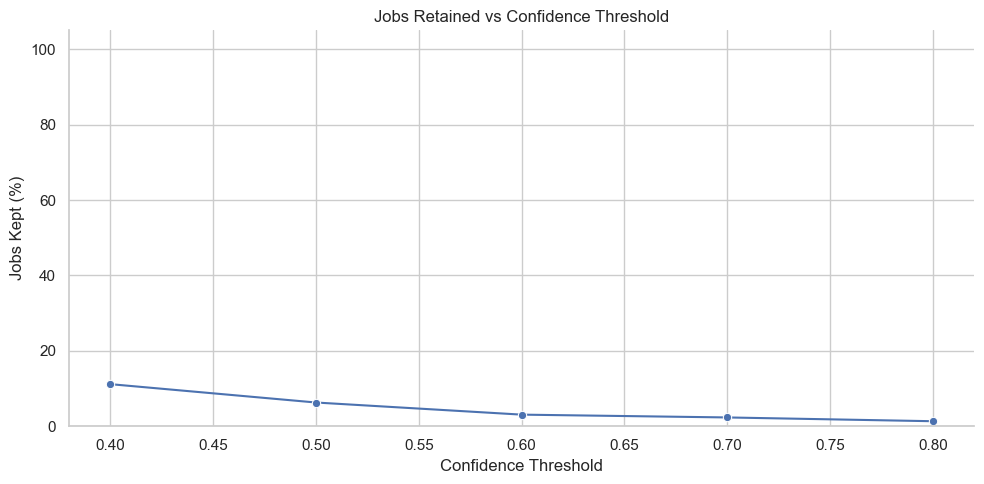

In [32]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=thr_df, x="Threshold", y="Jobs_Kept_%", marker="o")
plt.title("Jobs Retained vs Confidence Threshold")
plt.ylabel("Jobs Kept (%)")
plt.xlabel("Confidence Threshold")
plt.ylim(0, 105)
plt.tight_layout()
plt.show()



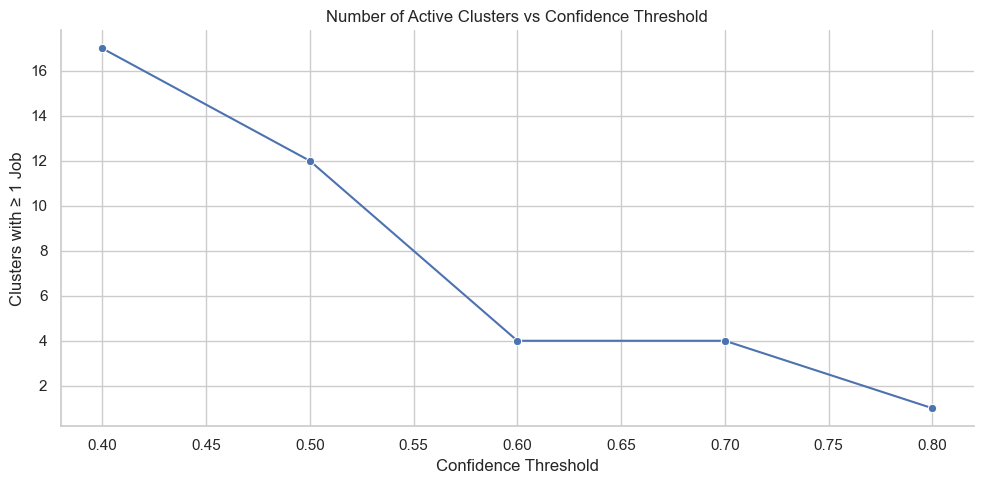

In [33]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=thr_df, x="Threshold", y="Clusters_Active", marker="o")
plt.title("Number of Active Clusters vs Confidence Threshold")
plt.ylabel("Clusters with ≥ 1 Job")
plt.xlabel("Confidence Threshold")
plt.tight_layout()
plt.show()



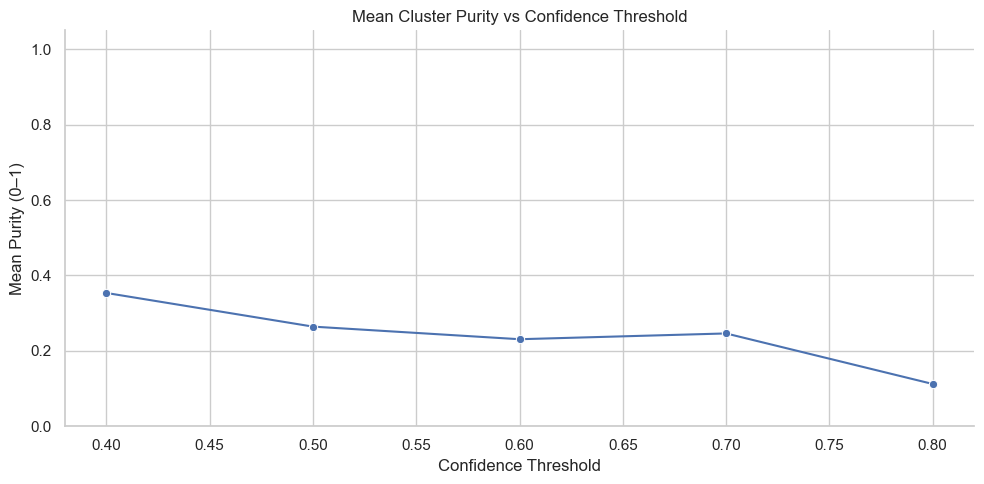

In [34]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=thr_df, x="Threshold", y="Mean_Cluster_Purity", marker="o")
plt.title("Mean Cluster Purity vs Confidence Threshold")
plt.ylabel("Mean Purity (0–1)")
plt.xlabel("Confidence Threshold")
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

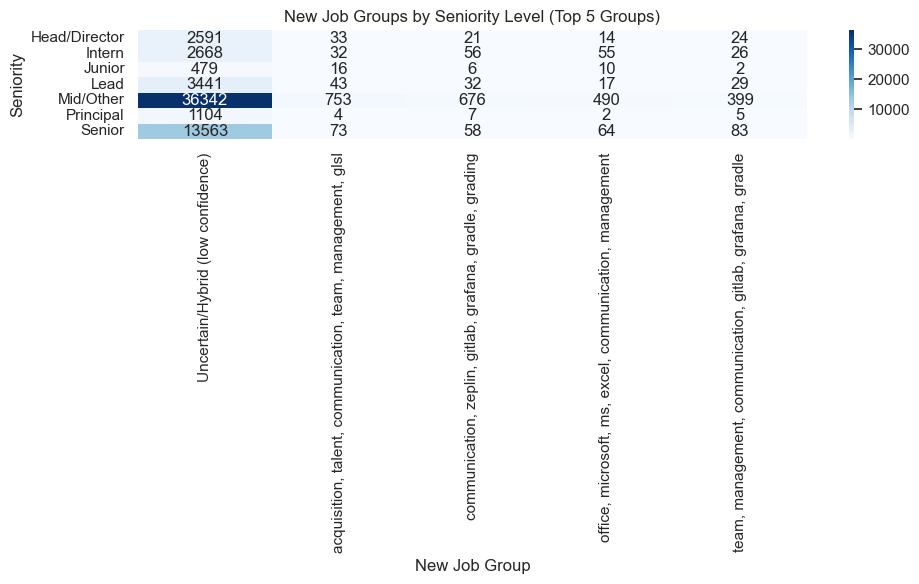

In [35]:
# 15) SENIORITY ANALYSIS (NEW GROUPS X SENIORITY, SALARY, CONFIDENCE)
# --------------------------------------------------------------------
senior_cat = pd.crosstab(df["Seniority"], df["New_Job_Group"])
top_new_by_sen = senior_cat.sum(axis=0).sort_values(ascending=False).head(5).index
senior_cat_small = senior_cat[top_new_by_sen]

plt.figure(figsize=(10, 6))
sns.heatmap(senior_cat_small, annot=True, fmt="d", cmap="Blues")
plt.title("New Job Groups by Seniority Level (Top 5 Groups)")
plt.ylabel("Seniority")
plt.xlabel("New Job Group")
plt.tight_layout()
plt.show()



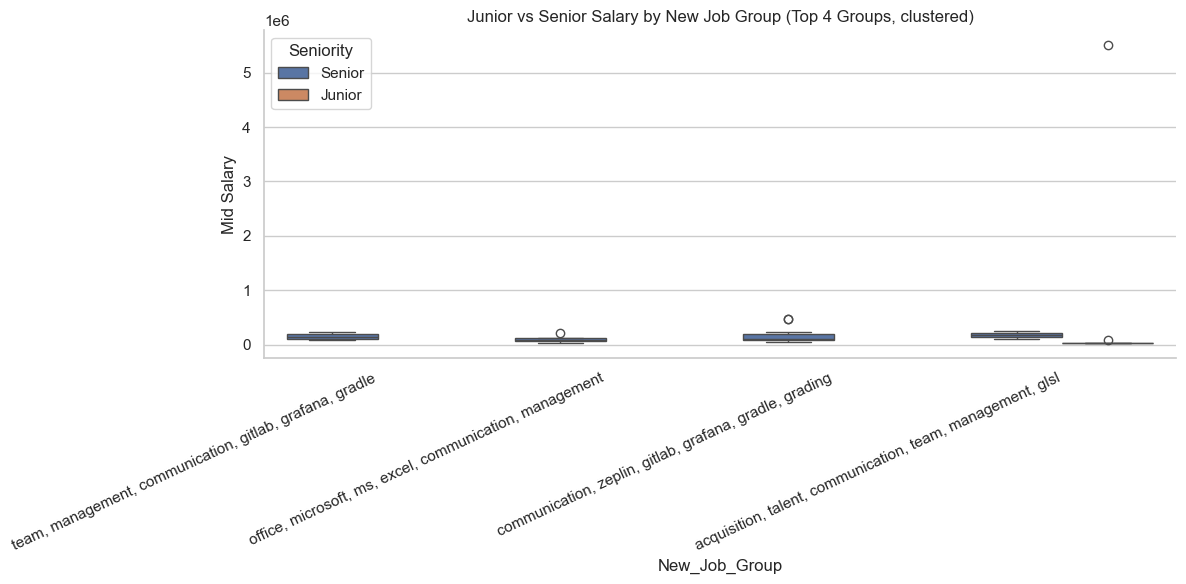

In [36]:
df_js = df[(df["Seniority"].isin(["Junior", "Senior"])) & (df["Mid_Salary"].notna()) & (df["Cluster_ID"] != -1)].copy()
if not df_js.empty:
    top_new_js = df_js["New_Job_Group"].value_counts().head(4).index
    df_js = df_js[df_js["New_Job_Group"].isin(top_new_js)]

    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df_js, x="New_Job_Group", y="Mid_Salary", hue="Seniority")
    plt.title("Junior vs Senior Salary by New Job Group (Top 4 Groups, clustered)")
    plt.xticks(rotation=25, ha="right")
    plt.ylabel("Mid Salary")
    plt.tight_layout()
    plt.show()






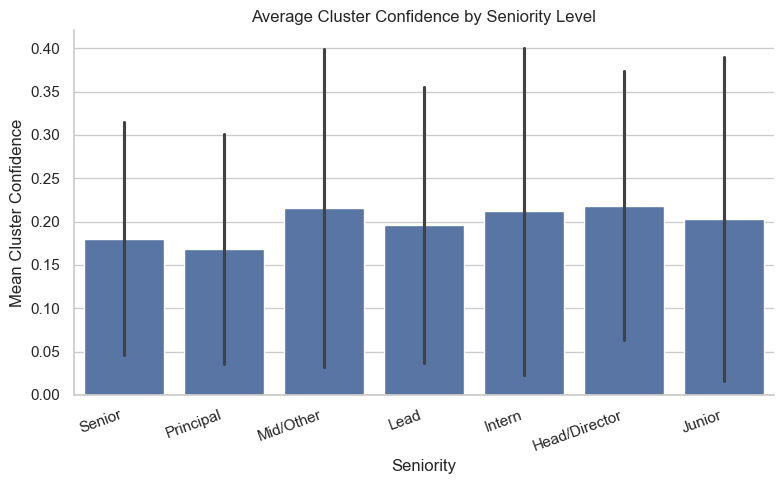

In [37]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x="Seniority", y="Cluster_Conf", estimator=np.mean, errorbar="sd")
plt.title("Average Cluster Confidence by Seniority Level")
plt.ylabel("Mean Cluster Confidence")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

In [38]:
# 16) CLUSTER SUMMARY TABLE (ADVANCED TAXONOMY)
# ----------------------------------------------------
def top_n(series, n=5):
    return ", ".join(series.value_counts().head(n).index.astype(str))

df_sk2 = df[["Cluster_ID", "Skills_CLEAN"]].copy()
df_sk2["Skills_List"] = df_sk2["Skills_CLEAN"].fillna("").str.split(",")
df_sk2 = df_sk2.explode("Skills_List")
df_sk2["Skills_List"] = df_sk2["Skills_List"].str.strip().str.lower()
df_sk2 = df_sk2[df_sk2["Skills_List"] != ""]

cluster_summary_rows = []
for cid, sub in df.groupby("Cluster_ID"):
    size = int(len(sub))
    mean_conf = float(sub["Cluster_Conf"].mean())
    median_salary = float(sub["Mid_Salary"].median()) if sub["Mid_Salary"].notna().any() else np.nan
    salary_count = int(sub["Mid_Salary"].notna().sum())

    cat_dist = sub["Overall Job Category"].value_counts(normalize=True)
    top_orig_cat = cat_dist.index[0] if not cat_dist.empty else None
    top_orig_cat_prop = float(cat_dist.iloc[0]) if not cat_dist.empty else np.nan
    n_orig_cats = int(cat_dist.size)

    top_countries_str = top_n(sub["Country"], n=3)
    skills_sub = df_sk2[df_sk2["Cluster_ID"] == cid]["Skills_List"]
    top_skills_str = top_n(skills_sub, n=6)
    gaming_share = float(sub["Gaming_Flag"].mean())

    cluster_summary_rows.append({
        "Cluster_ID": cid,
        "New_Job_Group": sub["New_Job_Group"].iloc[0],
        "Size": size,
        "Mean_Confidence": mean_conf,
        "Median_Mid_Salary": median_salary,
        "Salary_Count": salary_count,
        "Top_Original_Category": top_orig_cat,
        "Top_Original_Category_Pct": top_orig_cat_prop,
        "Num_Original_Categories": n_orig_cats,
        "Top_Countries": top_countries_str,
        "Top_Skills": top_skills_str,
        "Gaming_Share": gaming_share
    })

cluster_summary = pd.DataFrame(cluster_summary_rows).sort_values("Size", ascending=False)
display(cluster_summary.head(10))



,Cluster_ID,New_Job_Group,Size,Mean_Confidence,Median_Mid_Salary,Salary_Count,Top_Original_Category,Top_Original_Category_Pct,Num_Original_Categories,Top_Countries,Top_Skills,Gaming_Share
0,-1,Uncertain/Hybrid (low confidence),60188,0.174405,157450.0,18711,Engineering & Development,0.253323,32,"United States, India, United Kingdom","communication, team-management, cross-functional, talent-acquisition, python, problem-solving",0.089237
2,5,"acquisition, talent, communication, team, management, glsl",954,0.680317,118192.0,190,Customer & Community Support,0.255765,29,"Australia, United States, United Kingdom","talent-acquisition, communication, team-management",0.024109
3,6,"communication, zeplin, gitlab, grafana, gradle, grading",856,1.000000,84924.0,222,Facilities & Maintenance,0.112150,31,"United States, India, France",communication,0.025701
6,10,"office, microsoft, ms, excel, communication, management",652,0.576663,73840.0,167,Operations & Admin,0.128834,26,"United States, India, United Kingdom","ms-office, microsoft-office, communication, excel, team-management, talent-acquisition",0.012270
8,13,"team, management, communication, gitlab, grafana, gradle",568,0.526302,127300.0,160,Operations & Admin,0.133803,30,"United States, India, Mexico","team-management, communication, management",0.042254
5,8,"problem, solving, communication, team, management, game",276,0.535938,70720.0,50,Engineering & Development,0.184783,23,"United States, India, China","problem-solving, communication, team-management, loopback",0.007246
11,17,"cad, aided, computer, design, communication, management",180,0.604732,124250.0,91,Engineering & Development,0.400000,21,"United States, Canada, United Kingdom","cad-computer-aided-design, communication, team-management, python, cross-functional, cpp",0.083333
4,7,"control, quality, communication, team, management, gl",165,0.513995,142308.0,31,QA / QAE,0.254545,21,"United States, India, Mexico","quality-control, communication, team-management",0.000000
9,15,"budget, management, team, communication, gitlab, graphics",137,0.513410,126250.0,22,Operations & Admin,0.255474,18,"United States, India, Mexico","budget-management, team-management, communication",0.029197
1,1,"market, research, communication, team, management, cross",136,0.542641,176000.0,37,Business Development & Sales,0.250000,18,"United States, United Kingdom, India","market-research, communication, team-management, cross-functional, talent-acquisition, excel",0.014706


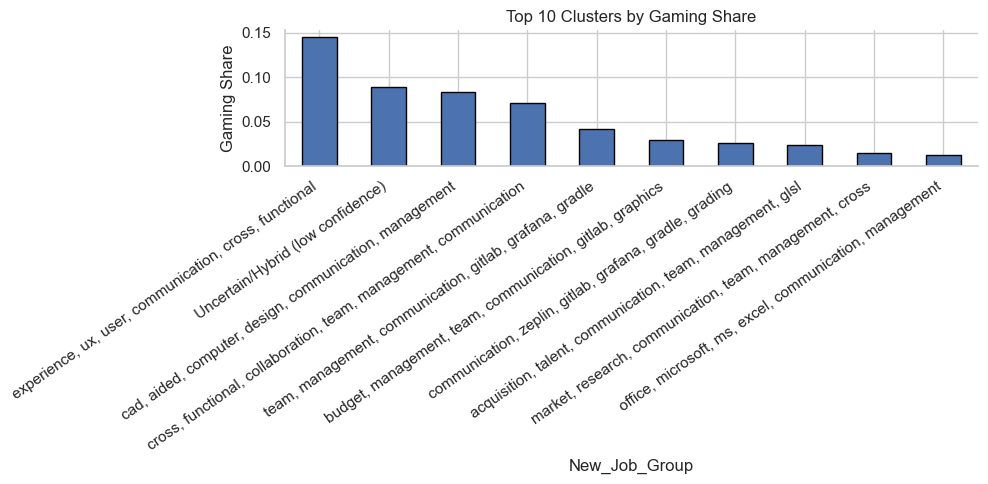

In [39]:
# Gaming share by cluster (ties strongly to title)
gaming_by_cluster = df.groupby("New_Job_Group")["Gaming_Flag"].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 5))
gaming_by_cluster.plot(kind="bar", edgecolor="black")
plt.title("Top 10 Clusters by Gaming Share")
plt.ylabel("Gaming Share")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()



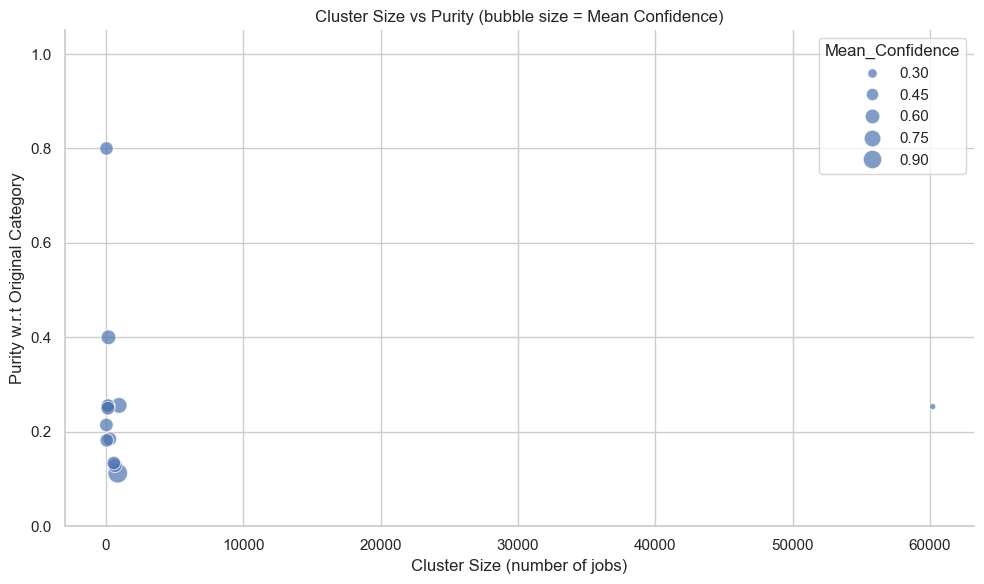

In [40]:
# Purity vs size
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=cluster_summary,
    x="Size",
    y="Top_Original_Category_Pct",
    size="Mean_Confidence",
    sizes=(20, 200),
    alpha=0.7
)
plt.title("Cluster Size vs Purity (bubble size = Mean Confidence)")
plt.xlabel("Cluster Size (number of jobs)")
plt.ylabel("Purity w.r.t Original Category")
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()


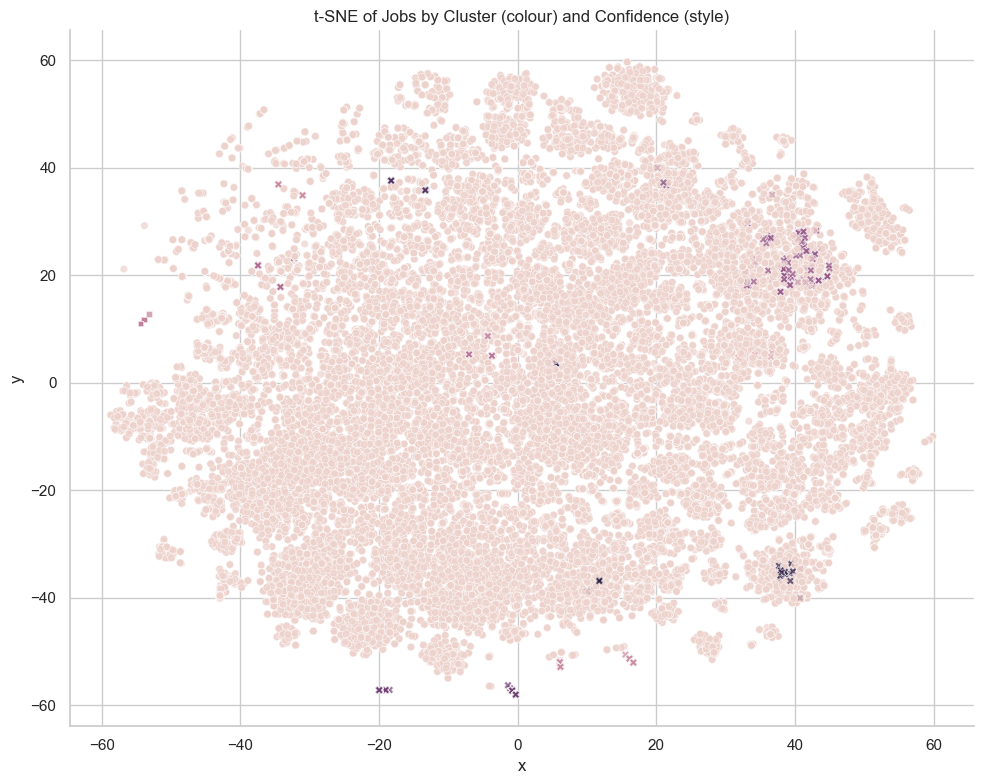

In [41]:
# 17) t-SNE VISUALISATION (FIXED INIT)
# -------------------------------------------
if best_space == "svd" and X_red is not None:
    X_for_tsne = X_red
else:
    X_for_tsne = X_tfidf.toarray()

tsne = TSNE(
    n_components=2,
    random_state=SEED,
    perplexity=50,
    learning_rate=200,
    init="random"
)
X_tsne = tsne.fit_transform(X_for_tsne)

df_tsne = pd.DataFrame({
    "x": X_tsne[:, 0],
    "y": X_tsne[:, 1],
    "Cluster_ID": df["Cluster_ID"],
    "Conf_Level": df["Conf_Level"]
})

plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=df_tsne,
    x="x", y="y",
    hue="Cluster_ID",
    style="Conf_Level",
    alpha=0.7,
    s=30,
    legend=False
)
plt.title("t-SNE of Jobs by Cluster (colour) and Confidence (style)")
plt.tight_layout()
plt.show()




 Gaming-only: k=40, silhouette=0.084
 Non-gaming-only: k=40, silhouette=0.096


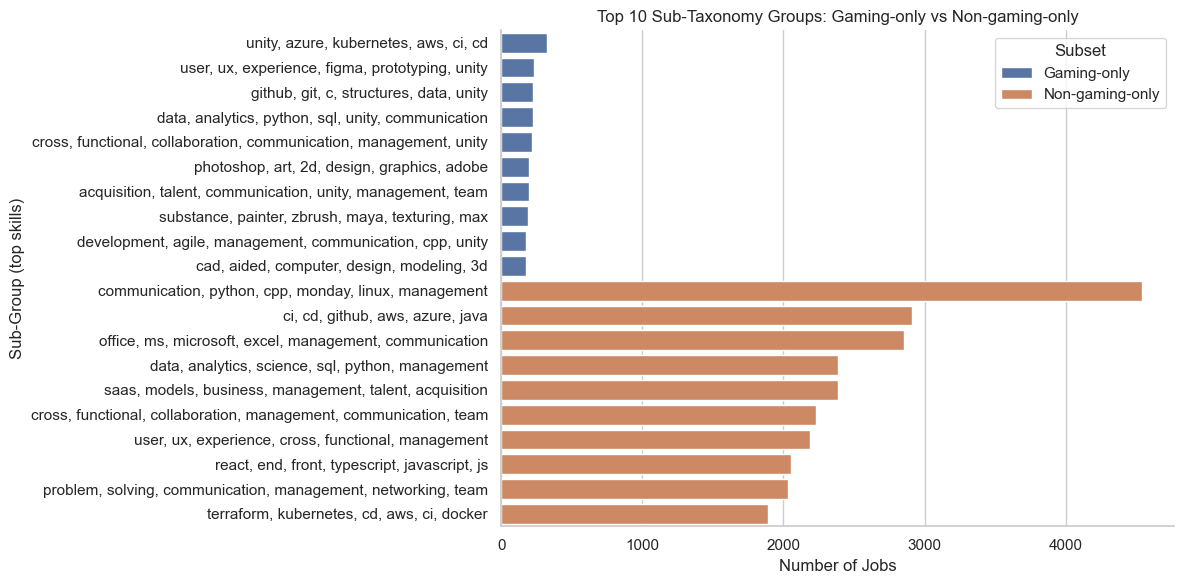

In [42]:
# 18) GAMING-ONLY VS NON-GAMING-ONLY TAXONOMIES
# -----------------------------
def build_subtaxonomy(df_sub, label):
    """
    Builds a quick taxonomy on a subset (gaming-only or non-gaming-only).
    Returns a summary dataframe of top groups + silhouette for that subset.
    """
    if len(df_sub) < 200:
        print(f" {label}: subset too small ({len(df_sub)} rows). Skipping.")
        return None, None

    tf = TfidfVectorizer(token_pattern=r"(?u)\b\w+\b", min_df=3, max_df=0.9)
    X = tf.fit_transform(df_sub["Skills_CLEAN"])
    feats = np.array(tf.get_feature_names_out())

    # Use a moderate k based on subset size
    k = int(np.clip(np.sqrt(len(df_sub)), 10, 40))
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    labs = km.fit_predict(X)
    sil = silhouette_score(X, labs)

    # Name clusters
    names = {}
    for cl in sorted(set(labs)):
        idx = np.where(labs == cl)[0]
        centroid = X[idx].mean(axis=0)
        centroid = np.asarray(centroid).ravel()
        top_idx = centroid.argsort()[::-1][:6]
        names[cl] = ", ".join(feats[top_idx])

    df_tmp = df_sub.copy()
    df_tmp["Sub_Cluster"] = labs
    df_tmp["Sub_Group"] = df_tmp["Sub_Cluster"].map(names)

    summ = df_tmp["Sub_Group"].value_counts().head(10).reset_index()
    summ.columns = ["Sub_Group", "Count"]
    summ["Subset"] = label
    print(f" {label}: k={k}, silhouette={sil:.3f}")
    return summ, sil

gaming_df = df[df["Gaming_Flag"] == 1].copy()
nongaming_df = df[df["Gaming_Flag"] == 0].copy()

gaming_summ, gaming_sil = build_subtaxonomy(gaming_df, "Gaming-only")
nongaming_summ, nongaming_sil = build_subtaxonomy(nongaming_df, "Non-gaming-only")

if gaming_summ is not None and nongaming_summ is not None:
    both = pd.concat([gaming_summ, nongaming_summ], ignore_index=True)

    plt.figure(figsize=(12, 6))
    sns.barplot(data=both, y="Sub_Group", x="Count", hue="Subset")
    plt.title("Top 10 Sub-Taxonomy Groups: Gaming-only vs Non-gaming-only")
    plt.ylabel("Sub-Group (top skills)")
    plt.xlabel("Number of Jobs")
    plt.tight_layout()
    plt.show()




In [43]:
# 19) EVALUATION SUMMARY (FOR PORTFOLIO / REPORT)
# --------------------------------------------------
eval_summary = {
    "Final_Method": best["method"],
    "Clusters_Final": int(df[df["Cluster_ID"] != -1]["Cluster_ID"].nunique()),
    "Silhouette_Final": float(best["silhouette"]),
    "Mean_Confidence": float(df["Cluster_Conf"].mean()),
    "Median_Confidence": float(df["Cluster_Conf"].median()),
    "Uncertain_<0.5_%": float((df["Cluster_Conf"] < 0.5).mean() * 100),
    "Clustered_>=0.5_%": float((df["Cluster_Conf"] >= 0.5).mean() * 100),
}
display(pd.DataFrame([eval_summary]))




,Final_Method,Clusters_Final,Silhouette_Final,Mean_Confidence,Median_Confidence,Uncertain_<0.5_%,Clustered_>=0.5_%
0,KMeans_k20,12,0.069584,0.205886,0.161636,93.706991,6.293009


In [44]:
# 20) SAVE FINAL ARTIFACTS (FINAL VERSION)
# -----------------------------
df.to_csv("FINAL_jobs_with_taxonomy_v2.csv", index=False)
cluster_summary.to_csv("FINAL_cluster_summary_v2.csv", index=False)
thr_df.to_csv("FINAL_conf_threshold_experiments_v2.csv", index=False)
kendall_df.to_csv("FINAL_kendall_tau_top_categories_v2.csv", index=False)

with open("FINAL_model_card_v2.txt", "w") as f:
    f.write("FINAL PROJECT ARTIFACT\n")
    f.write("----------------------\n")
    f.write(f"Final clustering method: {best['method']}\n")
    f.write(f"Clusters (excluding uncertain): {df[df['Cluster_ID']!=-1]['Cluster_ID'].nunique()}\n")
    f.write(f"Silhouette: {best['silhouette']}\n")
    f.write(f"Mean confidence: {df['Cluster_Conf'].mean():.4f}\n")
    f.write(f"Median confidence: {df['Cluster_Conf'].median():.4f}\n")
    f.write(f"Uncertain (<0.5): {(df['Cluster_Conf'] < 0.5).mean()*100:.2f}%\n")
    if gaming_sil is not None:
        f.write(f"Gaming-only sub-taxonomy silhouette: {gaming_sil:.3f}\n")
    if nongaming_sil is not None:
        f.write(f"Non-gaming-only sub-taxonomy silhouette: {nongaming_sil:.3f}\n")

print("\n Saved FINAL artifacts:")
print(" - FINAL_jobs_with_taxonomy_v2.csv")
print(" - FINAL_cluster_summary_v2.csv")
print(" - FINAL_conf_threshold_experiments_v2.csv")
print(" - FINAL_kendall_tau_top_categories_v2.csv")
print(" - FINAL_model_card_v2.txt")


 Saved FINAL artifacts:
 - FINAL_jobs_with_taxonomy_v2.csv
 - FINAL_cluster_summary_v2.csv
 - FINAL_conf_threshold_experiments_v2.csv
 - FINAL_kendall_tau_top_categories_v2.csv
 - FINAL_model_card_v2.txt


In [45]:

# Just for saving the pictures

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.manifold import TSNE

FIG_DIR = "figures"
os.makedirs(FIG_DIR, exist_ok=True)

TAX_PATH = "FINAL_jobs_with_taxonomy_v2.csv"
assert os.path.exists(TAX_PATH), f"Missing {TAX_PATH}. Run your 'SAVE FINAL ARTIFACTS' cell first."

df = pd.read_csv(TAX_PATH)

def find_col(df, candidates):
    cols = {c.lower(): c for c in df.columns}
    for cand in candidates:
        if cand.lower() in cols:
            return cols[cand.lower()]
    for cand in candidates:
        for c in df.columns:
            if cand.lower() in c.lower():
                return c
    return None

# --- Find the columns as they exist in YOUR notebook outputs ---
skills_col   = find_col(df, ["Skills_CLEAN", "Skills Clean", "skills_clean", "Skills", "skills"])
cluster_col  = find_col(df, ["Cluster_ID", "cluster_id", "Cluster", "cluster"])
conf_col     = find_col(df, ["Cluster_Conf", "cluster_conf", "confidence", "conf"])
cat_col      = find_col(df, ["Overall Job Category", "overall job category", "Job Category", "job category", "Category"])

if skills_col is None:
    raise ValueError("Could not find a skills column. Expected something like Skills_CLEAN or Skills.")
if cluster_col is None:
    raise ValueError("Could not find Cluster_ID column in FINAL_jobs_with_taxonomy_v2.csv")
if conf_col is None:
    raise ValueError("Could not find Cluster_Conf (confidence) column in FINAL_jobs_with_taxonomy_v2.csv")
if cat_col is None:
    raise ValueError("Could not find Overall Job Category column in FINAL_jobs_with_taxonomy_v2.csv")

# Clean minimal
df[skills_col] = df[skills_col].fillna("").astype(str)
df[cluster_col] = pd.to_numeric(df[cluster_col], errors="coerce").fillna(-1).astype(int)
df[conf_col] = pd.to_numeric(df[conf_col], errors="coerce")



In [46]:
# =========================
# FIGURE 1: Cluster sizes
# =========================
cluster_counts = df[df[cluster_col] != -1][cluster_col].value_counts().sort_index()

plt.figure(figsize=(10, 5))
cluster_counts.plot(kind="bar")
plt.xlabel("Cluster ID")
plt.ylabel("Number of Jobs")
plt.title("Cluster Size Distribution")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/cluster_sizes_bar.png", dpi=300, bbox_inches="tight")
plt.close()



In [47]:

# TF-IDF setup (based on YOUR Skills_CLEAN / Skills)

tfidf = TfidfVectorizer(
    token_pattern=r'(?u)\b\w[\w-]+\b',
    min_df=5,
    max_df=0.95
)
X = tfidf.fit_transform(df[skills_col])
feature_names = np.array(tfidf.get_feature_names_out())



In [48]:

# Re-index clusters to start from 0

unique_clusters = sorted(df[cluster_col].unique())

cluster_map = {old: new for new, old in enumerate(unique_clusters)}

df[cluster_col] = df[cluster_col].map(cluster_map)

print("Cluster re-indexing applied:")
print(cluster_map)


for cid in [0, 1, 5, 12]:
    plot_top_skills(cid)



Cluster re-indexing applied:
{-1: 0, 1: 1, 5: 2, 6: 3, 7: 4, 8: 5, 10: 6, 12: 7, 13: 8, 15: 9, 16: 10, 17: 11, 18: 12}


NameError: name 'plot_top_skills' is not defined

In [ ]:

# FIGURE 2: Top skills for selected clusters

def plot_top_skills(cluster_id, top_n=10):
    idx = df.index[df[cluster_col] == cluster_id].to_numpy()

    if len(idx) < 5:
        print(f"⚠️ Cluster {cluster_id} has too few jobs ({len(idx)}). Skipping.")
        return

    mean_vec = X[idx].mean(axis=0).A1
    top_idx = mean_vec.argsort()[-top_n:][::-1]

    plt.figure(figsize=(8, 4))
    plt.barh(
        feature_names[top_idx][::-1],
        mean_vec[top_idx][::-1]
    )
    plt.xlabel("Mean TF-IDF Weight")
    plt.title(f"Top Skills – Cluster {cluster_id}")
    plt.tight_layout()
    plt.savefig(
        f"{FIG_DIR}/top_skills_cluster_{cluster_id}.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.close()

    print(f"Saved top_skills_cluster_{cluster_id}.png")




In [ ]:
for cid in [0, 1, 5, 12]:
    plot_top_skills(cid)


In [ ]:
# FIGURE 3: t-SNE (subsampled for speed)

SUBSAMPLE = min(10000, X.shape[0])
svd = TruncatedSVD(n_components=300, random_state=42)
X_red = svd.fit_transform(X[:SUBSAMPLE])

tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30,
    learning_rate=200,
    init="pca"
)
X_tsne = tsne.fit_transform(X_red)

plt.figure(figsize=(8, 6))
plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=df.loc[:SUBSAMPLE-1, cluster_col].to_numpy(),
    cmap="tab20",
    s=6
)
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("t-SNE Projection of Skill Space")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/tsne_clusters.png", dpi=300, bbox_inches="tight")
plt.close()



In [ ]:
# FIGURE 4: Confidence distribution 

conf_vals = df[conf_col].dropna().to_numpy()

plt.figure(figsize=(8, 5))
plt.hist(conf_vals, bins=np.arange(0, 1.05, 0.1), edgecolor="black")
plt.axvline(0.5, linestyle="--")
plt.xlabel("Cluster Confidence")
plt.ylabel("Number of Jobs")
plt.title("Confidence Score Distribution")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/confidence_binned_bar.png", dpi=300, bbox_inches="tight")
plt.close()



In [ ]:
# FIGURE 5: Category–cluster overlap heatmap

df_map = df[df[cluster_col] != -1].copy()
overlap = pd.crosstab(df_map[cat_col], df_map[cluster_col], normalize="index") * 100

plt.figure(figsize=(12, 8))
sns.heatmap(overlap, cmap="viridis")
plt.xlabel("Cluster ID")
plt.ylabel("Original Job Category")
plt.title("Category–Cluster Overlap Heatmap (%)")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/category_overlap_heatmap.png", dpi=300, bbox_inches="tight")
plt.close()

print("Dissertation figures saved in ./figures/")
print("Created files:")
for f in sorted(os.listdir(FIG_DIR)):
    print(" -", f)


In [ ]:
import os
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

# Save location
FIG_DIR = "figures"
os.makedirs(FIG_DIR, exist_ok=True)
out_path = os.path.join(FIG_DIR, "pipeline_overview.png")

# Steps 
steps = [
    "Data Collection\n(job postings + platform categories + raw skills)",
    "Skill Cleaning & Preprocessing\n(lowercase, trimming, token filtering, artefact handling)",
    "Feature Representation\n(TF–IDF vectorisation)",
    "Dimensionality Reduction\n(Truncated SVD, e.g., 300 components)",
    "Clustering\n(K-Means, k = 20; HDBSCAN explored)",
    "Confidence-Aware Assignment\n(distance-based probabilities + thresholding)",
    "Evaluation & Interpretation\n(silhouette, Kendall tau, dominant skills, visualisations)"
]

# Figure setup
fig, ax = plt.subplots(figsize=(12, 8))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")
fig.patch.set_facecolor("white")  # ensure white background

# Layout
box_x = 0.12
box_w = 0.78
box_h = 0.095
y_start = 0.88
y_gap = 0.03

# Styles (high contrast)
box_face = "#F2F2F2"   # very light grey
box_edge = "black"
arrow_col = "black"

for i, text in enumerate(steps, start=1):
    y = y_start - (i - 1) * (box_h + y_gap)

    # Main box
    rect = FancyBboxPatch(
        (box_x, y),
        box_w,
        box_h,
        boxstyle="round,pad=0.012,rounding_size=0.015",
        linewidth=1.8,
        edgecolor=box_edge,
        facecolor=box_face
    )
    ax.add_patch(rect)

    # Step indicator (left side, bold)
    ax.text(
        box_x - 0.055, y + box_h / 2,
        f"{i}",
        ha="center", va="center",
        fontsize=16, fontweight="bold", color="black"
    )

    # Step text
    ax.text(
        box_x + box_w / 2, y + box_h / 2,
        text,
        ha="center", va="center",
        fontsize=12, color="black"
    )

    # Arrow to next
    if i < len(steps):
        ax.annotate(
            "",
            xy=(0.51, y - 0.012),
            xytext=(0.51, y - y_gap + 0.012),
            arrowprops=dict(arrowstyle="->", linewidth=2.2, color=arrow_col),
            annotation_clip=False
        )

# Title 
ax.text(
    0.5, 0.97,
    "Methodological Pipeline (Skill-Based, Confidence-Aware Taxonomy)",
    ha="center", va="center",
    fontsize=14, fontweight="bold", color="black"
)

plt.tight_layout()
plt.savefig(out_path, dpi=300, bbox_inches="tight", facecolor="white")
plt.close()

print(f"Saved clear pipeline diagram to: {out_path}")


In [ ]:
import os
import matplotlib.pyplot as plt

FIG_DIR = "figures"
os.makedirs(FIG_DIR, exist_ok=True)
out_path = os.path.join(FIG_DIR, "pipeline_overview.png")

steps = [
    "1  Data Collection\n(Job postings + categories + skills)",
    "2  Cleaning & Preprocessing\n(Normalise skills, remove noise)",
    "3  TF–IDF Vectorisation\n(Interpretable skill features)",
    "4  Truncated SVD\n(Reduce dimensionality)",
    "5  K-Means Clustering (k=20)\n(Group jobs by skill profiles)",
    "6  Confidence Scoring\n(Soft assignment + thresholding)",
    "7  Evaluation & Reporting\n(Silhouette, Kendall tau, plots)"
]

fig, ax = plt.subplots(figsize=(10, 7))
ax.axis("off")
fig.patch.set_facecolor("white")

# Text box style (simple + clear)
bbox = dict(boxstyle="round,pad=0.6", facecolor="#F7F7F7", edgecolor="black", linewidth=1.5)

# Layout positions
x = 0.5
y = 0.9
dy = 0.12

# Draw boxes and arrows
for i, s in enumerate(steps):
    ax.text(x, y - i*dy, s, ha="center", va="center", fontsize=12, color="black", bbox=bbox)
    if i < len(steps) - 1:
        ax.annotate(
            "",
            xy=(x, y - (i+1)*dy + 0.045),
            xytext=(x, y - i*dy - 0.045),
            arrowprops=dict(arrowstyle="->", linewidth=2.0, color="black")
        )

# Optional title
ax.text(0.5, 0.98, "Pipeline Overview", ha="center", va="center",
        fontsize=14, fontweight="bold", color="black")

plt.tight_layout()
plt.savefig(out_path, dpi=300, bbox_inches="tight", facecolor="white")
plt.close()

print(f"Saved pipeline diagram to: {out_path}")


In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# RAW DATASET SAMPLE TABLE
# =========================

FIG_DIR = "figures"
os.makedirs(FIG_DIR, exist_ok=True)

# Load raw dataset
df_raw = pd.read_csv("Combined Data.csv")

# Helper to find columns robustly
def find_col(df, candidates):
    for c in df.columns:
        for cand in candidates:
            if cand.lower() in c.lower():
                return c
    return None

title_col = find_col(df_raw, ["title"])
cat_col   = find_col(df_raw, ["category"])
skill_col = find_col(df_raw, ["skill"])

if skill_col is None or title_col is None or cat_col is None:
    raise ValueError("Required columns (title, category, skills) not found.")

# Take a small illustrative sample
sample_df = df_raw[[title_col, cat_col, skill_col]].head(5).copy()

# Truncate very long skill strings for readability
sample_df[skill_col] = sample_df[skill_col].astype(str).str.slice(0, 80) + "..."

# Rename columns for presentation
sample_df.columns = ["Job Title", "Platform Category", "Raw Skill List"]

# Create table figure
fig, ax = plt.subplots(figsize=(12, 3))
ax.axis("off")
fig.patch.set_facecolor("white")

table = ax.table(
    cellText=sample_df.values,
    colLabels=sample_df.columns,
    loc="center",
    cellLoc="left"
)

# Styling
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.6)

# Bold header
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(weight="bold")
        cell.set_facecolor("#F0F0F0")

# Save
out_path = os.path.join(FIG_DIR, "raw_dataset_table.png")
plt.tight_layout()
plt.savefig(out_path, dpi=300, bbox_inches="tight", facecolor="white")
plt.close()

print(f"Saved raw dataset table to: {out_path}")


In [ ]:
import os
import matplotlib.pyplot as plt

# Ensure figures directory exists
os.makedirs("figures", exist_ok=True)

# Example values (replace with your actual counts if you have them)
labels = [
    "Raw skill tokens",
    "After cleaning",
    "After frequency filtering"
]

values = [
    18500,   # example: raw unique skills
    12400,   # example: after normalisation
    8600     # example: after min_df / max_df filtering
]

# Create figure
plt.figure(figsize=(8, 5))
plt.bar(labels, values)
plt.ylabel("Number of unique skill tokens")
plt.xlabel("Preprocessing stage")
plt.title("Impact of preprocessing on skill vocabulary size")

# Rotate labels slightly for readability
plt.xticks(rotation=10)

# Tight layout for LaTeX compatibility
plt.tight_layout()

# Save figure (exact name used in LaTeX)
plt.savefig("figures/preprocessing_before_after.png", dpi=300)

# Show figure
plt.show()
